In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Загрузка изображения:

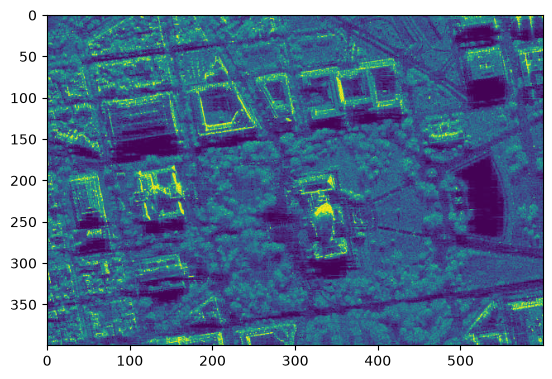

In [2]:
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image)

Гистограмма:

In [3]:
histSize = 256
histRange = (0, 256)
accumulate = False

image_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

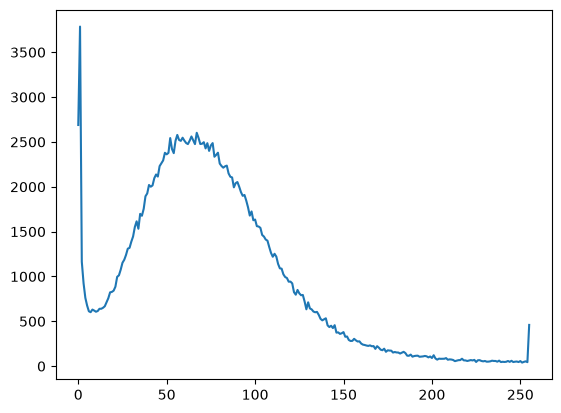

In [4]:
plt.plot(image_hist)

Алгоритм гамма коррекции:

In [5]:
def adjust_gamma(image, gamma=1.0):
    inv_gamma = 1.0 / gamma
    table = np.array([
        ((i / 255.0) ** inv_gamma) * 255
        for i in np.arange(0, 256)
    ]).astype("uint8")
    return cv2.LUT(image, table)

gammas = [0.7, 1.5] 

results = {}
for g in gammas:
    results[g] = adjust_gamma(image, gamma=g)

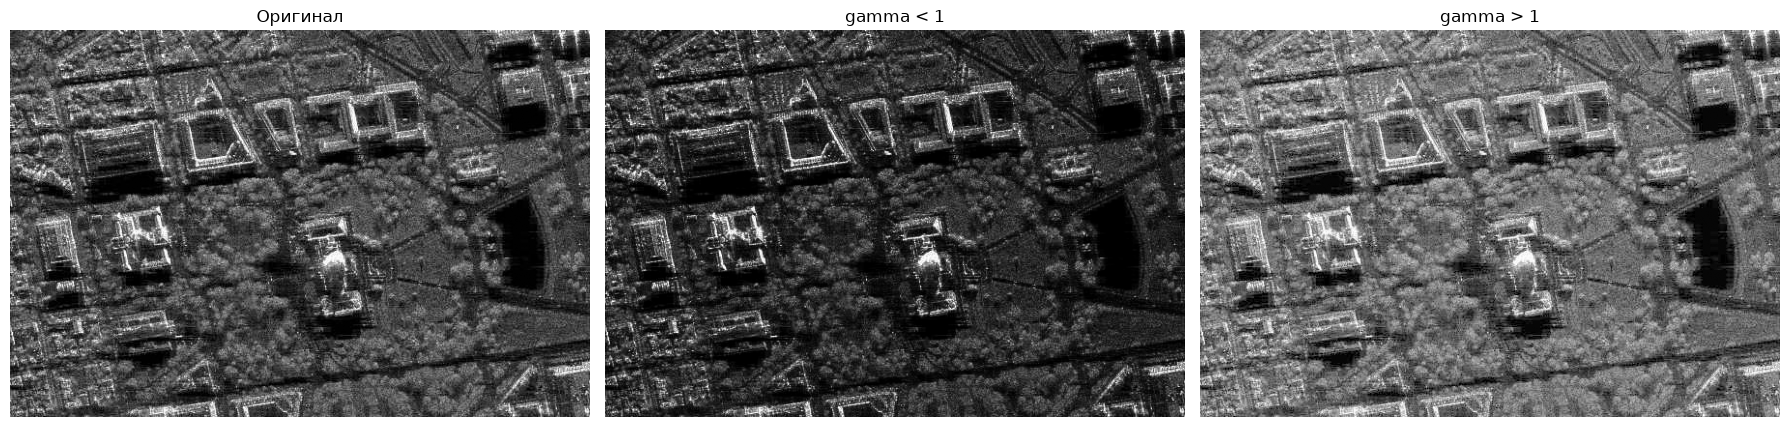

In [6]:
plt.figure(figsize=(18, 6))

plt.subplot(1, len(gammas) + 1, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

for i, g in enumerate(gammas, start=2):
    plt.subplot(1, len(gammas) + 1, i)
    plt.imshow(results[g], cmap='gray')
    label = 'gamma < 1' if g < 1 else 'gamma > 1'
    plt.title(f'{label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Сравнение:

In [7]:
print(f"{'Изображение':<20}{'MSE':>12}{'SSIM':>12}")
print("-" * 44)

for g in gammas:
    corrected = results[g]

    mse  = mean_squared_error(image, corrected)
    ssim = structural_similarity(image, corrected)

    tag = 'gamma < 1' if g < 1 else 'gamma > 1'
    print(f"gamma = {g} ({tag:<9}) {mse:>12.4f} {ssim:>12.4f}")

Изображение                  MSE        SSIM
--------------------------------------------
gamma = 0.7 (gamma < 1)     774.6754       0.8471
gamma = 1.5 (gamma > 1)    1114.4519       0.8940


Цветокоррекция:

In [9]:
print("=== Статистическая цветокоррекция ===")

eq_gray = cv2.equalizeHist(image)

target_mean = eq_gray.mean()
target_std  = eq_gray.std()

source_mean = image.mean()
source_std  = image.std()

print(f"Оригинал (image): mean = {source_mean:6.2f}, std = {source_std:6.2f}")
print(f"Эталон  (eq_gray):     mean = {target_mean:6.2f}, std = {target_std:6.2f}")

if source_std > 0:
    corrected = (image.astype(np.float32) - source_mean) \
                * (target_std / source_std) + target_mean
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
else:
    corrected = image.copy()
    print("std исходника = 0, преобразование не применено.")

print(f"Результат:             mean = {corrected.mean():6.2f}, std = {corrected.std():6.2f}")

=== Статистическая цветокоррекция ===
Оригинал (image): mean =  74.94, std =  43.66
Эталон  (eq_gray):     mean = 127.03, std =  74.27
Результат:             mean = 123.12, std =  65.30


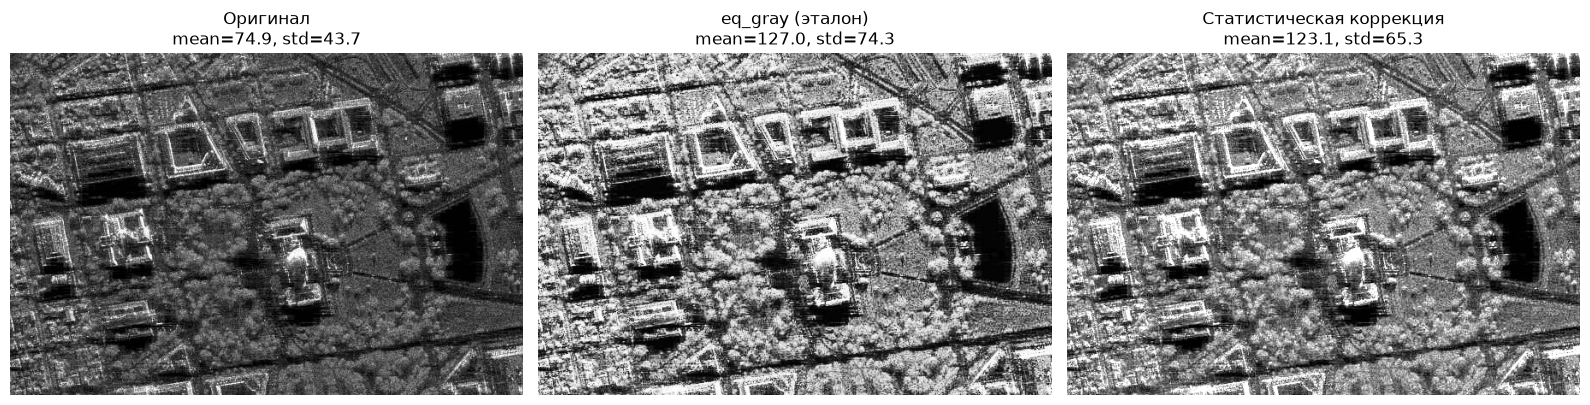

In [10]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title(f'Оригинал\nmean={source_mean:.1f}, std={source_std:.1f}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title(f'eq_gray (эталон)\nmean={target_mean:.1f}, std={target_std:.1f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(corrected, cmap='gray')
plt.title(f'Статистическая коррекция\nmean={corrected.mean():.1f}, std={corrected.std():.1f}')
plt.axis('off')

plt.tight_layout()
plt.show()

Пороговая фильтрация с разными параметрами:

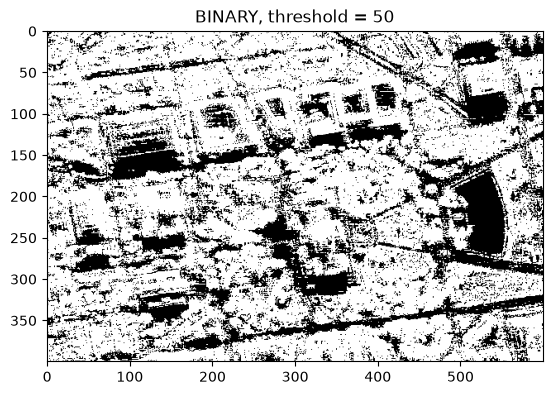

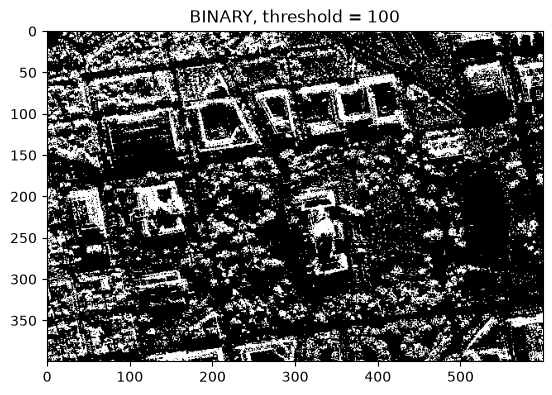

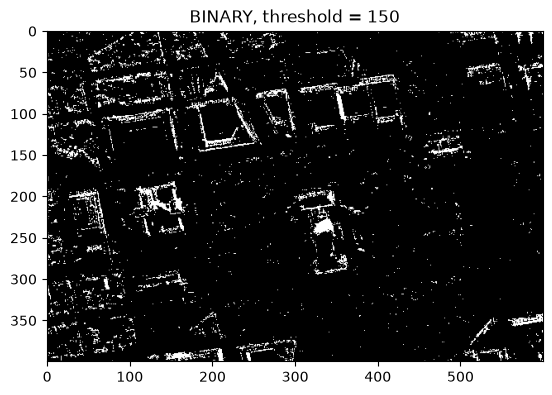

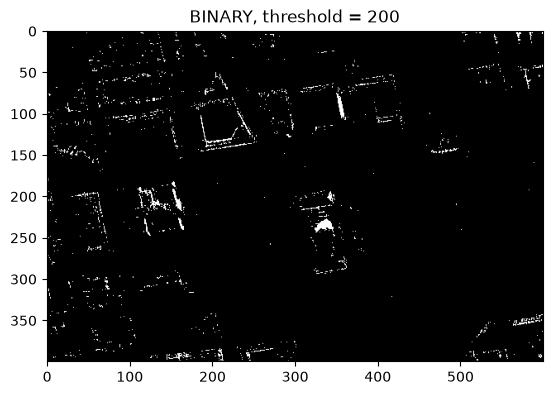

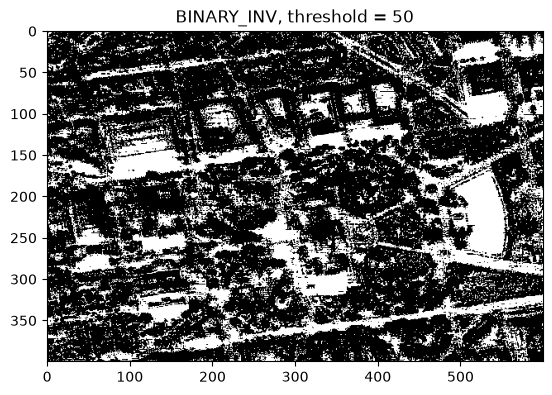

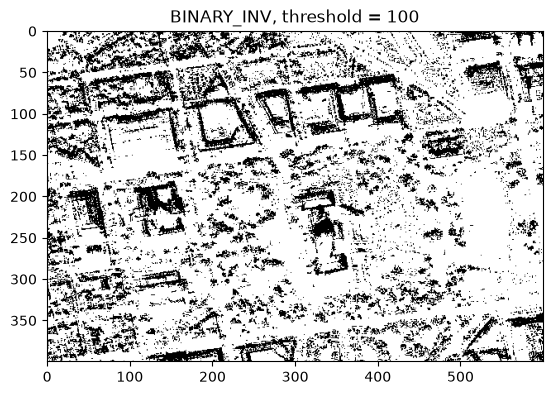

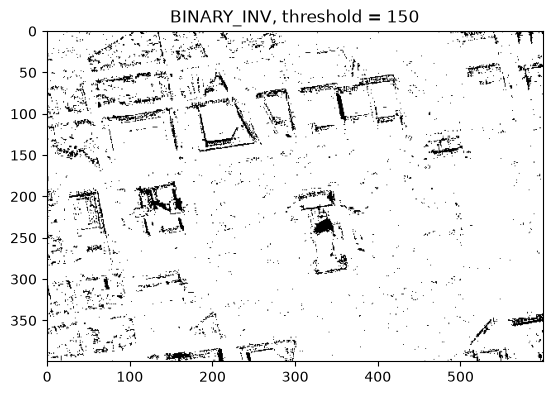

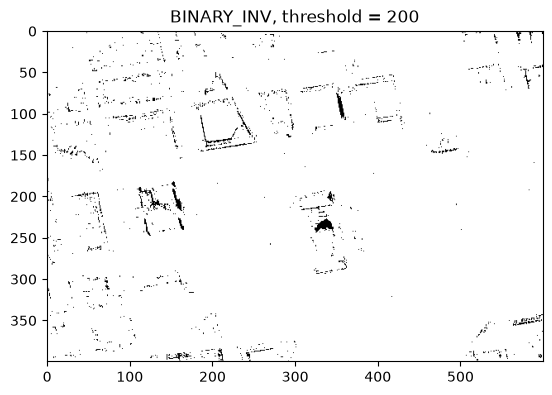

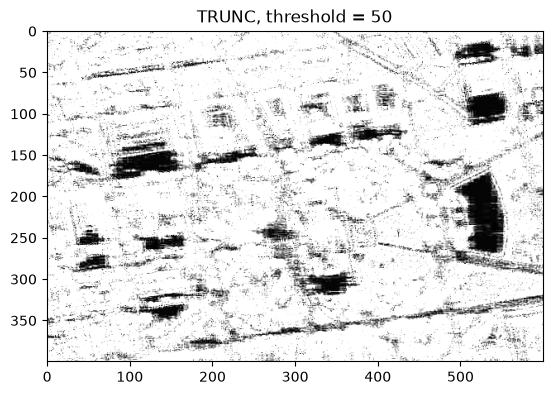

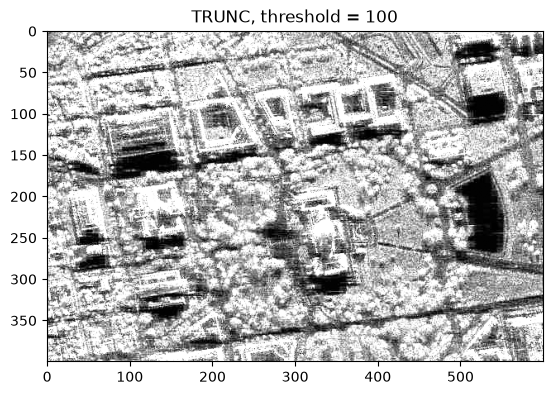

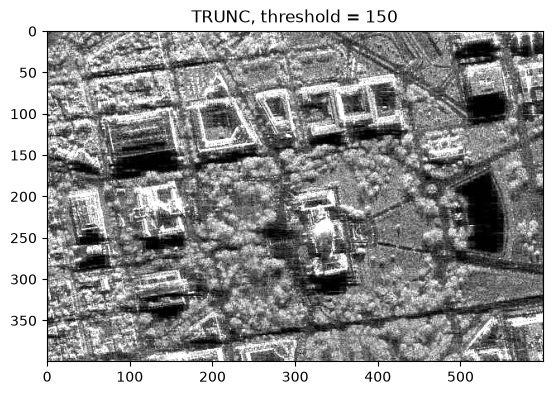

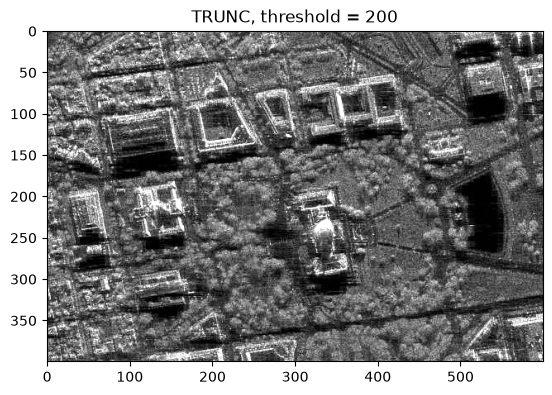

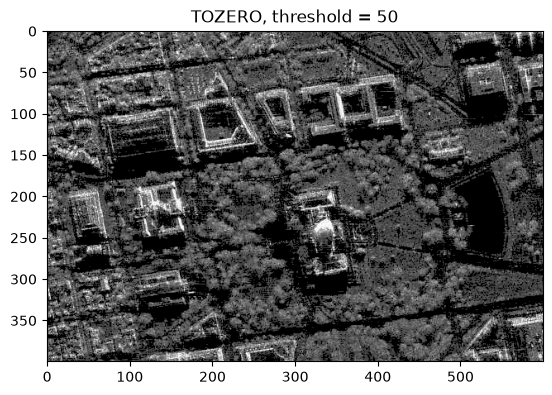

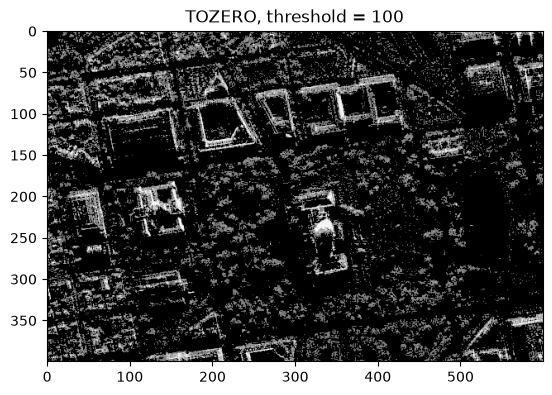

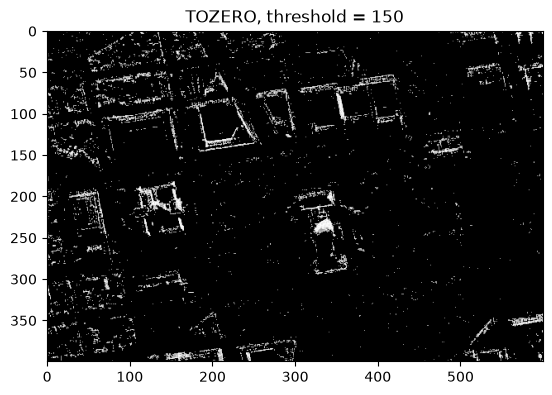

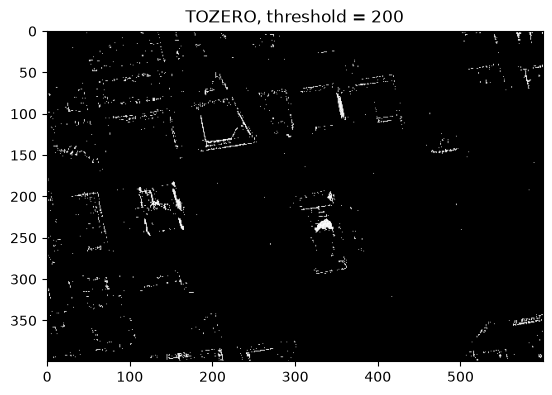

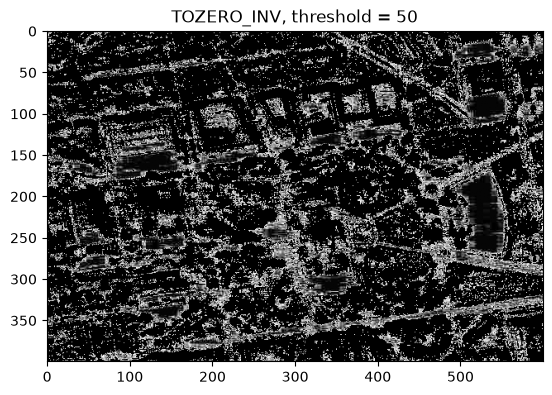

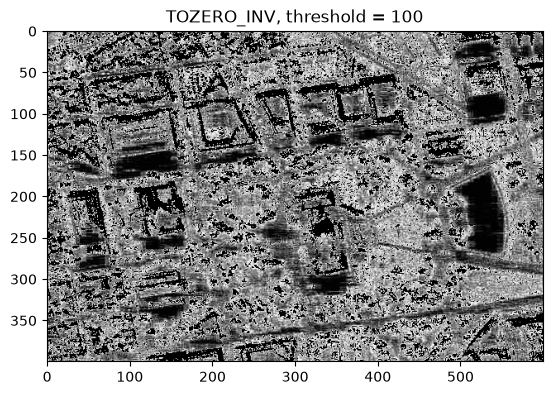

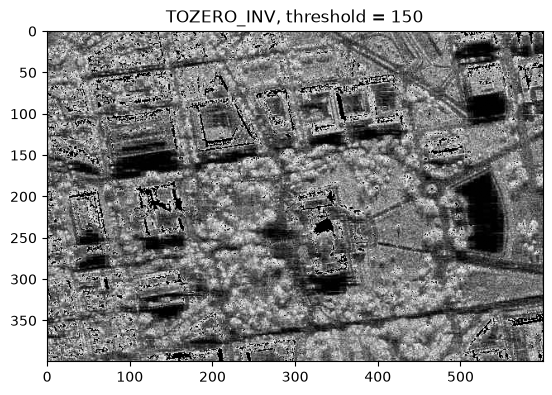

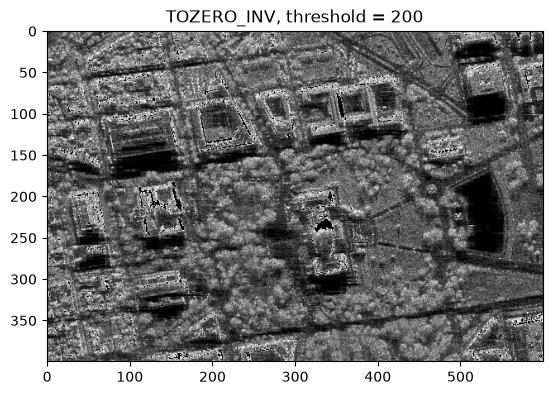

In [12]:
threshold_types = [
    (cv2.THRESH_BINARY,     "BINARY"),
    (cv2.THRESH_BINARY_INV, "BINARY_INV"),
    (cv2.THRESH_TRUNC,      "TRUNC"),
    (cv2.THRESH_TOZERO,     "TOZERO"),
    (cv2.THRESH_TOZERO_INV, "TOZERO_INV"),
]

thresholds = [50, 100, 150, 200]

for ttype, tname in threshold_types:
    for thresh in thresholds:
        _, th = cv2.threshold(image, thresh, 255, ttype)
        above = int((image > thresh).sum())
        plt.imshow(th, cmap="gray")
        plt.title(f"{tname}, threshold = {thresh}")
        plt.show()